# **Project Name**    - Yes Bank Stock Closing Price Prediction (Regression)



# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [10]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# common look for all the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'


### Dataset Loading

In [11]:
# Load Dataset
file_path = "D:\Downloads\data_YesBank_StockPrices.csv"
df = pd.read_csv(file_path)


### Dataset First View

In [12]:
# Dataset First Look
print('First 5 rows')
display(df.head())
print('\nLast 5 rows')
display(df.tail())


First 5 rows


,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41



Last 5 rows


,Date,Open,High,Low,Close
180,Jul-20,25.60,28.30,11.10,11.95
181,Aug-20,12.00,17.16,11.85,14.37
182,Sep-20,14.30,15.34,12.75,13.15
183,Oct-20,13.30,14.01,12.11,12.42
184,Nov-20,12.41,14.90,12.21,14.67


### Dataset Rows & Columns count

In [13]:
# Dataset Rows & Columns count
print('Number of rows    :', df.shape[0])
print('Number of columns :', df.shape[1])


Number of rows    : 185
Number of columns : 5


### Dataset Information

In [14]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [15]:
# Dataset Duplicate Value Count
print('Duplicate rows  :', df.duplicated().sum())
print('Duplicate months:', df['Date'].duplicated().sum())


Duplicate rows  : 0
Duplicate months: 0


#### Missing Values/Null Values

In [16]:
# Missing Values/Null Values Count
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())


Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Total missing values: 0


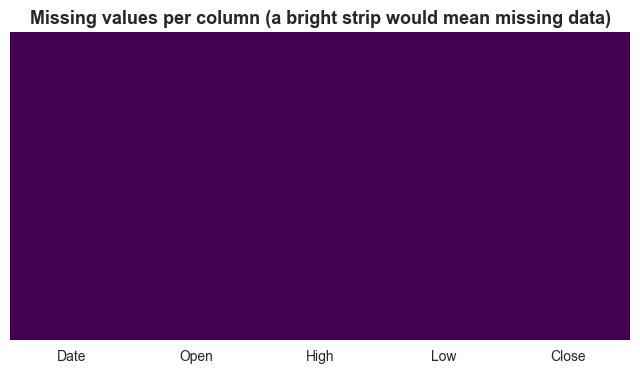

In [17]:
# Visualizing the missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing values per column (a bright strip would mean missing data)')
plt.show()


### What did you know about your dataset?

The dataset holds the monthly stock prices of Yes Bank from July 2005 to November 2020. It has 185 rows and 5 columns (Date, Open, High, Low, Close). There are no missing values, no duplicate rows and no duplicate months, and the timeline has no gaps, so every month in the period is present.

Date was loaded as plain text (like "Jul-05"), the other four columns are floats. The prices are right-skewed: the average closing price is about 105 but the median is only about 62, because the 2016-2018 rally pulled a few months very high. The target for this project is the **Close** price and the problem type is **regression**.

## ***2. Understanding Your Variables***

In [18]:
# Dataset Columns
print(list(df.columns))


['Date', 'Open', 'High', 'Low', 'Close']


In [19]:
# Dataset Describe
df.describe().round(2)


,Open,High,Low,Close
count,185.00,185.00,185.00,185.00
mean,105.54,116.10,94.95,105.20
std,98.88,106.33,91.22,98.58
min,10.00,11.24,5.55,9.98
25%,33.80,36.14,28.51,33.45
50%,62.98,72.55,58.00,62.54
75%,153.00,169.19,138.35,153.30
max,369.95,404.00,345.50,367.90


### Variables Description

| Variable | Meaning |
|---|---|
| Date | The month and year of the record (e.g. Jul-05). Converted to a datetime during wrangling. |
| Open | Price of the stock at the start of the month (INR). |
| High | The highest price touched during the month. |
| Low | The lowest price touched during the month. |
| Close | Price at the end of the month. This is the **target** we want to predict. |

Describe() shows the closing price ranging from 9.98 (March 2009) to 367.90 (July 2018). The High column goes up to 404 and the Low column goes down to 5.55 (March 2020). The standard deviation of Close is about 98, almost the same as its mean, which tells us the price level changed a lot over the years.

### Check Unique Values for each variable.

In [20]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f'{col:<6} -> {df[col].nunique()} unique values')


Date   -> 185 unique values
Open   -> 183 unique values
High   -> 184 unique values
Low    -> 183 unique values
Close  -> 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [21]:
# Write your code to make your dataset analysis ready.

# 1. Date is stored like "Jul-05" (text), so convert it to a proper datetime.
#    %b = short month name, %y = 2 digit year
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# 2. make sure rows are in time order
df = df.sort_values('Date').reset_index(drop=True)

# 3. extra columns that help in the analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Range'] = df['High'] - df['Low']                      # how far the price moved inside the month
df['Change'] = df['Close'] - df['Open']                   # close minus open
df['Change_Pct'] = (df['Close'] / df['Open'] - 1) * 100   # same thing in percent
df['Direction'] = np.where(df['Change'] >= 0, 'Up', 'Down')

# 4. sanity checks on the data itself
wrong_rows = df[(df['High'] < df[['Open', 'Low', 'Close']].max(axis=1)) |
                (df['Low'] > df[['Open', 'High', 'Close']].min(axis=1))]
print('Rows where High/Low logic breaks :', len(wrong_rows))

all_months = pd.date_range(df['Date'].min(), df['Date'].max(), freq='MS')
print('Months missing in the timeline   :', len(all_months) - df['Date'].nunique())
print('Period covered                   :', df['Date'].min().strftime('%b %Y'), 'to', df['Date'].max().strftime('%b %Y'))

df.head()


Rows where High/Low logic breaks : 0
Months missing in the timeline   : 0
Period covered                   : Jul 2005 to Nov 2020


,Date,Open,High,Low,Close,Year,Month,Month_Name,Range,Change,Change_Pct,Direction
0,2005-07-01,13.00,14.00,11.25,12.46,2005,7,Jul,2.75,-0.54,-4.153846,Down
1,2005-08-01,12.58,14.88,12.55,13.42,2005,8,Aug,2.33,0.84,6.677266,Up
2,2005-09-01,13.48,14.87,12.27,13.30,2005,9,Sep,2.60,-0.18,-1.335312,Down
3,2005-10-01,13.20,14.47,12.40,12.99,2005,10,Oct,2.07,-0.21,-1.590909,Down
4,2005-11-01,13.35,13.88,12.88,13.41,2005,11,Nov,1.00,0.06,0.449438,Up


### What all manipulations have you done and insights you found?

What we did in wrangling:

- Converted `Date` from text ("Jul-05") to a real datetime using the format `%b-%y`, and sorted the rows by date.
- Created Year, Month and Month_Name columns so we can group the data by period in the charts.
- Created `Range` (High - Low), `Change` (Close - Open), `Change_Pct` and `Direction` (Up/Down month). These are only used for analysis and charts. They are not given to the model because Change and Direction are made using Close, which would leak the target.
- Checked that High is really the highest and Low really the lowest value of every month (0 rows broken) and that there are no missing months in the timeline.

Things we found: the data is clean, the series is continuous for 185 months, and there were 100 months that closed higher than they opened against 85 months that closed lower.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

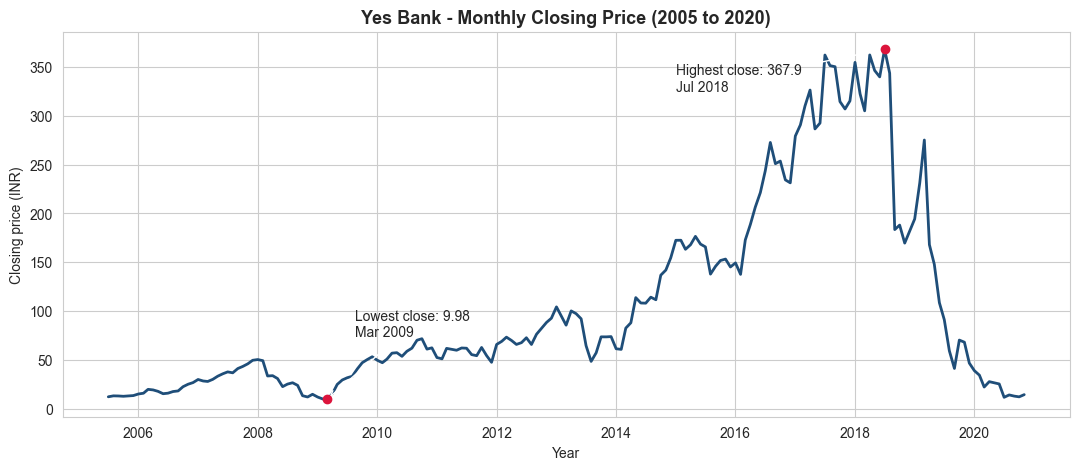

In [22]:
# Chart - 1 visualization code
plt.figure(figsize=(13, 5))
plt.plot(df['Date'], df['Close'], color='#1f4e79', linewidth=2)

top = df.loc[df['Close'].idxmax()]
bottom = df.loc[df['Close'].idxmin()]
plt.scatter([top['Date'], bottom['Date']], [top['Close'], bottom['Close']], color='crimson', zorder=5)
plt.annotate(f"Highest close: {top['Close']:.1f}\n{top['Date']:%b %Y}", (top['Date'], top['Close']),
             xytext=(-150, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Lowest close: {bottom['Close']:.2f}\n{bottom['Date']:%b %Y}", (bottom['Date'], bottom['Close']),
             xytext=(20, 45), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('Yes Bank - Monthly Closing Price (2005 to 2020)')
plt.xlabel('Year')
plt.ylabel('Closing price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A line chart is the natural way to look at a price that changes with time. It shows the trend, the turning points and the big jumps in one picture, and the highest and lowest points are marked so they are easy to find.

##### 2. What is/are the insight(s) found from the chart?

The price stayed around 12-20 in 2005-2006, rose to about 50 by late 2007, and dropped to its lowest close of 9.98 in March 2009 (the global financial crisis period). From 2010 it climbed steadily, crossed 100 in 2013-2014 and then rallied hard to a peak close of 367.9 in July 2018. After that the price fell sharply: from 343.4 in August 2018 to 183.45 in September 2018, a small recovery to about 275 in March 2019, and then a long slide to around 12-15 in the second half of 2020. So the price at the end of the data is almost back at where it started in 2005.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the 2010-2018 uptrend shows the period in which the bank was growing and the market rewarded it, so this part of the history is useful for learning how the price behaves in a growth phase.

Negative: the fall after July 2018 is huge. A close of 367.9 to 11.95 in July 2020 is a loss of about 97% of the value, and the chart shows that the drop was fast, not gradual. For an investor or the bank itself this is a warning that a long rise can be erased within two years, which means risk monitoring has to be continuous and not based only on past gains.

#### Chart - 2

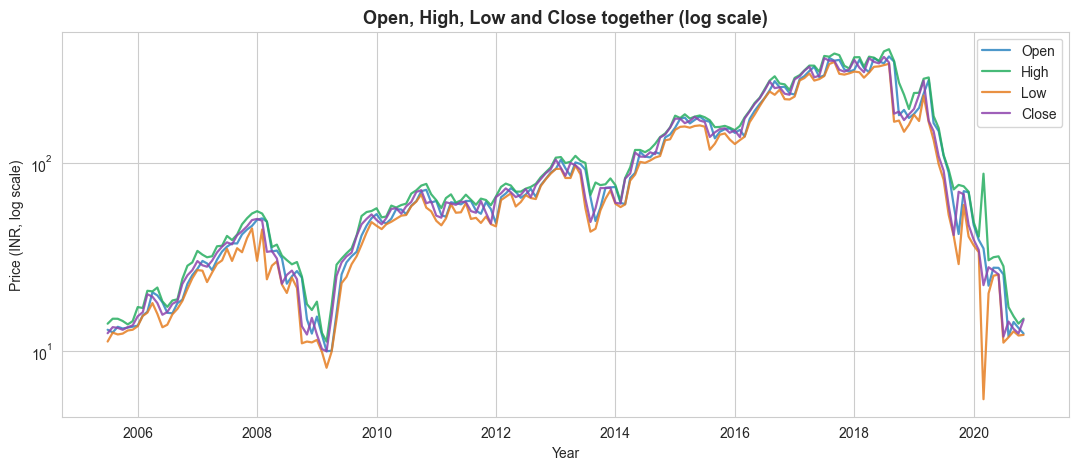

In [23]:
# Chart - 2 visualization code
plt.figure(figsize=(13, 5))
for col, colour in zip(['Open', 'High', 'Low', 'Close'], ['#2e86c1', '#27ae60', '#e67e22', '#8e44ad']):
    plt.plot(df['Date'], df[col], label=col, color=colour, linewidth=1.6, alpha=0.85)

plt.yscale('log')   # log scale so the early low-price years are visible too
plt.title('Open, High, Low and Close together (log scale)')
plt.xlabel('Year')
plt.ylabel('Price (INR, log scale)')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

We wanted to compare all four price columns together. Plotting Open, High, Low and Close as separate lines on one chart shows how close they are to each other and when they separate. A log scale was used because the prices range from about 6 to 400, and on a normal scale the early years would look flat.

##### 2. What is/are the insight(s) found from the chart?

The four lines almost sit on top of each other for most of the period, which means that within a month the price usually does not move very far from where it opened. The gap between High and Low is narrow in the calm years (2010-2017) and becomes much wider from late 2018 onwards, especially in 2019-2020, where Low falls far below Open and High. In March 2020 the High is 87.95 while the Low is 5.55, the widest gap in the whole dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: since Open, High and Low follow Close so closely, we can expect a model to predict Close well using them. That is good for building a reliable estimator.

Negative: the widening gap in 2018-2020 shows rising intramonth uncertainty. A business that depended on a stable price (for example one using the shares as collateral) would have faced larger swings exactly when the price was also falling.

#### Chart - 3

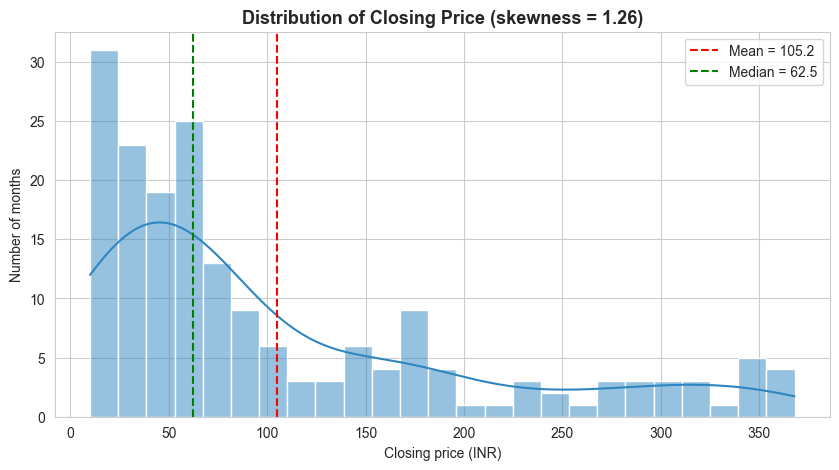

In [24]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 5))
sns.histplot(df['Close'], bins=25, kde=True, color='#2e86c1')
plt.axvline(df['Close'].mean(), color='red', linestyle='--', label=f"Mean = {df['Close'].mean():.1f}")
plt.axvline(df['Close'].median(), color='green', linestyle='--', label=f"Median = {df['Close'].median():.1f}")
plt.title(f"Distribution of Closing Price (skewness = {df['Close'].skew():.2f})")
plt.xlabel('Closing price (INR)')
plt.ylabel('Number of months')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE curve shows the shape of the closing-price distribution. The mean and median lines were added because the difference between them tells us directly about skewness.

##### 2. What is/are the insight(s) found from the chart?

The distribution is right-skewed (skewness about 1.26). The mean is about 105 but the median is only about 62.5. Most of the months are at lower prices: 121 of the 185 months closed below 100, and only 30 months closed above 200 (all between May 2016 and March 2019). The high-price region therefore has comparatively few data points.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is more of a modelling insight than a direct business one. Because high-price months are rare, a model trained on raw prices will pay most attention to the many low-price months and may be less accurate when the price is high, which is exactly when a mistake costs the most money. That is why we later apply a log transformation to make the distribution more symmetric (skewness comes down to almost 0).

#### Chart - 4

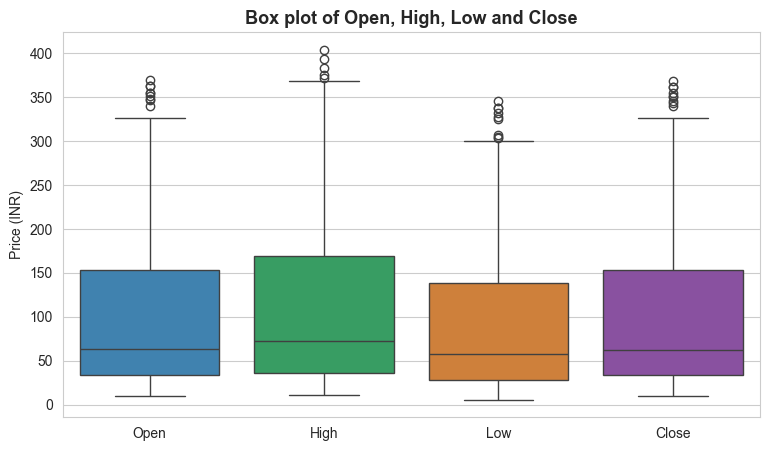

In [25]:
# Chart - 4 visualization code
plt.figure(figsize=(9, 5))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette=['#2e86c1', '#27ae60', '#e67e22', '#8e44ad'])
plt.title('Box plot of Open, High, Low and Close')
plt.ylabel('Price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A box plot summarises the spread (quartiles, median) of each price column and marks the outliers as separate dots. Putting the four columns side by side lets us compare them easily.

##### 2. What is/are the insight(s) found from the chart?

All four columns have nearly the same box: the median is around 58-73 and the middle 50% of values lie roughly between 30 and 170. The dots above the top whisker show outliers. By the IQR rule Open and Close have 9 outliers each, Low has 9 and High has 5, and all of them come from the 2017-2018 peak period. The Low column has the smallest minimum (5.55), which comes from March 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These outliers are not data entry errors, they are real months where the share traded at its all-time high levels. So removing them would delete genuine market behaviour and would hurt the business use of the model, because the model should also work for high prices. On the negative side, they show how extreme the price level became before the fall, which is a sign of an overheated rally.

#### Chart - 5

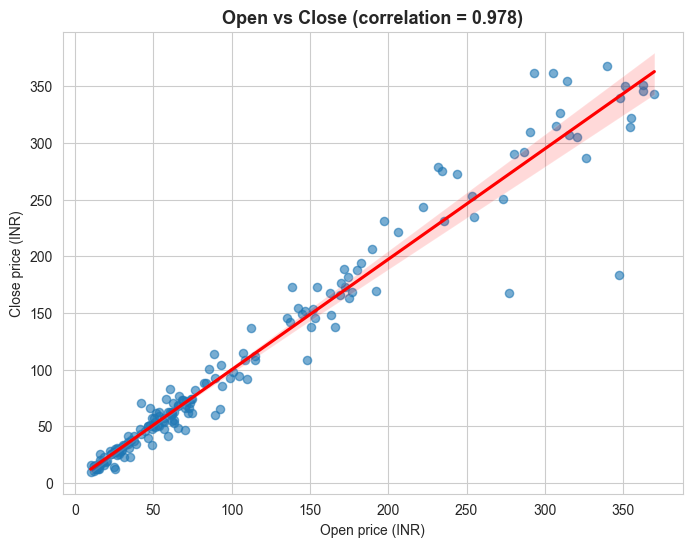

In [26]:
# Chart - 5 visualization code
plt.figure(figsize=(8, 6))
sns.regplot(x='Open', y='Close', data=df, scatter_kws={'alpha': 0.6, 's': 35}, line_kws={'color': 'red'})
plt.title(f"Open vs Close (correlation = {df['Open'].corr(df['Close']):.3f})")
plt.xlabel('Open price (INR)')
plt.ylabel('Close price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot with a regression line is the best way to check whether two numeric variables have a linear relationship, which is the main assumption of linear regression. Here it is used to see how well the opening price explains the closing price.

##### 2. What is/are the insight(s) found from the chart?

Open and Close have a very strong positive linear relationship (correlation = 0.978). The points follow the red line closely at low prices, and they spread out more as the price gets higher. This means that the month's closing price is usually close to the opening price, but at high prices the month-end movement can be larger.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Open is a strong and easily available predictor, so even a simple model can estimate the closing price with good accuracy, which makes the model cheap to build and easy to explain.

Negative: the points that are far from the line are months of sharp one-month moves (like September 2018, when the price opened at 347.2 and closed at 183.45). A model relying only on Open would miss exactly those events.

#### Chart - 6

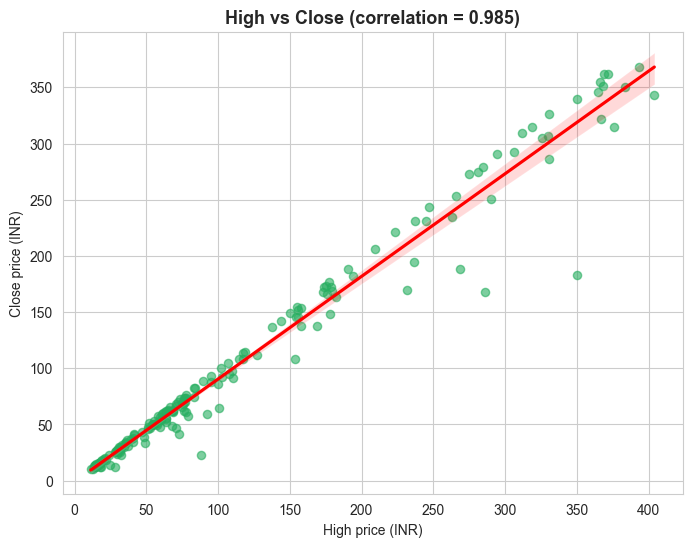

In [27]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 6))
sns.regplot(x='High', y='Close', data=df, color='#27ae60', scatter_kws={'alpha': 0.6, 's': 35}, line_kws={'color': 'red'})
plt.title(f"High vs Close (correlation = {df['High'].corr(df['Close']):.3f})")
plt.xlabel('High price (INR)')
plt.ylabel('Close price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

The same scatter plus regression line is used for High so that the three input columns can be compared on the same basis.

##### 2. What is/are the insight(s) found from the chart?

High and Close have a correlation of 0.985, a little stronger than Open. The relationship is clearly linear and the points are tighter around the line than they were for Open, though the spread still gets wider at higher prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: knowing how high the price went in a month tells a lot about where it ended, so High is a useful feature for estimating the close.

Negative: High is only known when the month is almost over, so it cannot be used for planning ahead. It is useful for explaining or estimating the month's close, not for forecasting the next one.

#### Chart - 7

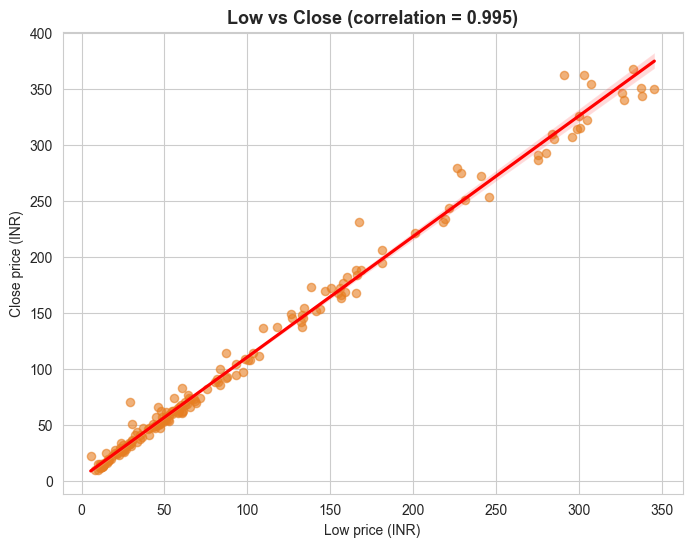

In [28]:
# Chart - 7 visualization code
plt.figure(figsize=(8, 6))
sns.regplot(x='Low', y='Close', data=df, color='#e67e22', scatter_kws={'alpha': 0.6, 's': 35}, line_kws={'color': 'red'})
plt.title(f"Low vs Close (correlation = {df['Low'].corr(df['Close']):.3f})")
plt.xlabel('Low price (INR)')
plt.ylabel('Close price (INR)')
plt.show()


##### 1. Why did you pick the specific chart?

Again a scatter plot with a regression line, now for the Low price, so we can compare which of the three inputs is closest to the target.

##### 2. What is/are the insight(s) found from the chart?

Low has the strongest relationship with Close of all the columns (correlation = 0.995), and the points are packed tightly along the line. In the random forest later, Low also gets the highest feature importance, which matches what we see here.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Low is the best single predictor, so the model can lean on it. The closing price is rarely far from the monthly low in this dataset.

Negative: the few points above the line (like October 2019, where Low is only 29.05 but Close is 70.45) are months where the price bounced back strongly. Those are the rebounds a Low-driven model will underestimate.

#### Chart - 8

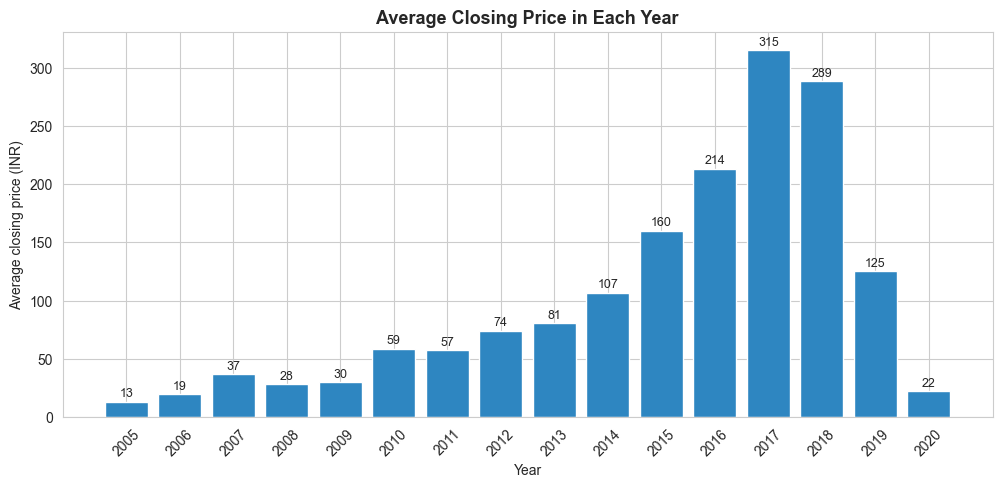

In [29]:
# Chart - 8 visualization code
yearly_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12, 5))
bars = plt.bar(yearly_avg.index.astype(str), yearly_avg.values, color='#2e86c1')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 4, f'{b.get_height():.0f}', ha='center', fontsize=9)
plt.title('Average Closing Price in Each Year')
plt.xlabel('Year')
plt.ylabel('Average closing price (INR)')
plt.xticks(rotation=45)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is a clean way to compare one value (average closing price) across categories (years), and the data labels make it easy to read exact numbers.

##### 2. What is/are the insight(s) found from the chart?

The average closing price rose almost every year: about 13 in 2005, 59 in 2010, 107 in 2014, 214 in 2016 and a peak of about 315 in 2017. After that it came down: 289 in 2018, 125 in 2019 and just 22 in 2020. So the bank's share went through a long growth cycle of 12 years and then lost most of it in 3 years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: 2010 to 2017 was a consistent growth period and the price multiplied more than five times (59 to 315), which is the kind of performance that attracts investors.

Negative: the 2018 to 2020 decline is the main negative growth signal. The 2020 average is lower than the 2007 average, so the gains of more than a decade were lost. A sudden fall like this points to company-specific problems and not just a market-wide correction.

#### Chart - 9

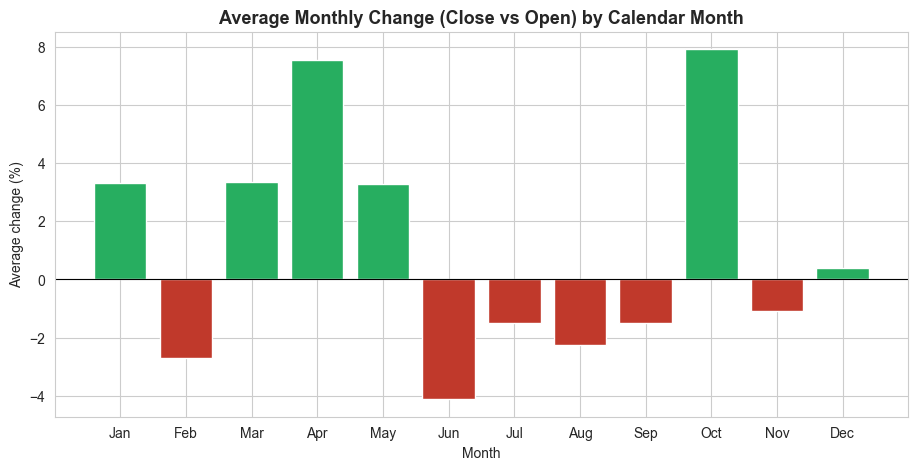

In [30]:
# Chart - 9 visualization code
# average % change (close vs open) for each calendar month
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_change = df.groupby('Month_Name')['Change_Pct'].mean().reindex(month_order)

plt.figure(figsize=(11, 5))
colours = ['#27ae60' if v >= 0 else '#c0392b' for v in monthly_change.values]
plt.bar(monthly_change.index, monthly_change.values, color=colours)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Monthly Change (Close vs Open) by Calendar Month')
plt.xlabel('Month')
plt.ylabel('Average change (%)')
plt.show()


##### 1. Why did you pick the specific chart?

Seasonality is a common question for stock data, so we wanted to see if any calendar month tends to do better. A bar chart coloured green (gain) and red (loss) shows the average monthly change immediately.

##### 2. What is/are the insight(s) found from the chart?

April (+7.6%) and October (+7.9%) have the highest average gains, followed by January, March and May at about +3.3%. June (-4.1%), February (-2.7%) and August (-2.3%) are the weakest. In April and October about 73-75% of the months were up months.

We should not over-read this chart though. Each calendar month has only 15-16 observations and a few extreme months (like October 2019 when the price jumped by about 68%) pull the averages a lot, so the pattern is not strong evidence of real seasonality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: a mild pattern of stronger April and October months can be a starting point for further testing, for example in timing purchases.

Negative: if someone built a strategy on this chart alone it could lead to wrong decisions, since the sample is small and driven by outliers. We therefore did not use Month as a model feature.

#### Chart - 10

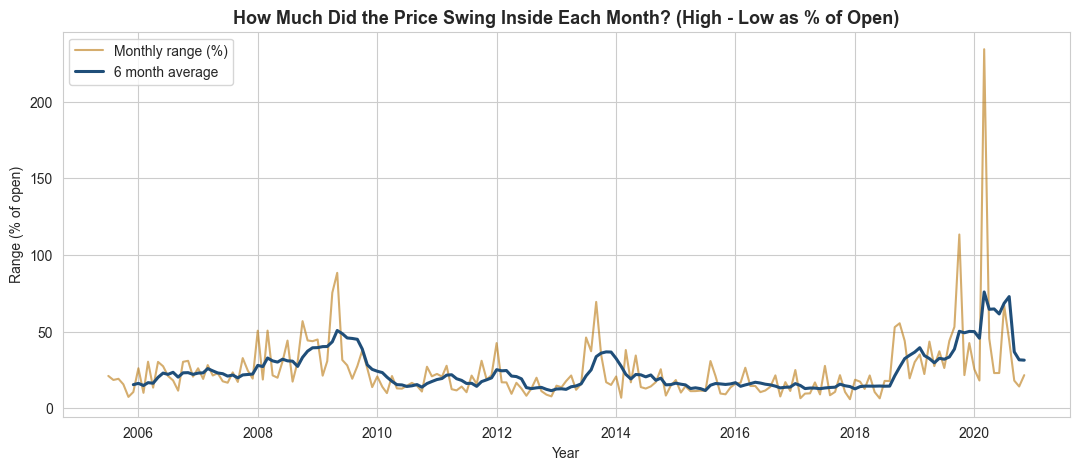

In [31]:
# Chart - 10 visualization code
df['Range_pct_plot'] = df['Range'] / df['Open'] * 100   # monthly range as % of the opening price

plt.figure(figsize=(13, 5))
plt.plot(df['Date'], df['Range_pct_plot'], color='#b9770e', alpha=0.6, label='Monthly range (%)')
plt.plot(df['Date'], df['Range_pct_plot'].rolling(6).mean(), color='#1f4e79', linewidth=2.2, label='6 month average')
plt.title('How Much Did the Price Swing Inside Each Month? (High - Low as % of Open)')
plt.xlabel('Year')
plt.ylabel('Range (% of open)')
plt.legend()
plt.show()

df = df.drop(columns='Range_pct_plot')


##### 1. Why did you pick the specific chart?

A line chart over time works well for volatility. We measured the swing in each month as (High - Low) / Open so that it is a percentage and can be compared across years even though the price level changed. The 6-month moving average smooths the noise and shows the trend.

##### 2. What is/are the insight(s) found from the chart?

The average swing is about 24% of the opening price (median about 19%). It was lowest in the stable growth years: about 13.5% in 2017 and 14-15% in 2012, 2015 and 2016. It was highest in 2008-2009 (about 36-37%) and especially in 2019 (about 41%) and 2020 (about 49%). The most extreme month is March 2020, where the gap between the High (87.95) and the Low (5.55) was about 234% of the opening price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: low-volatility periods like 2015-2017 coincide with the strongest price growth, which suggests that a steady market gave investors confidence.

Negative: volatility started rising again from 2018 before the large fall was finished, so this chart can work as an early warning indicator. Risk teams could set limits when the 6-month average range moves well above its normal level.

#### Chart - 11

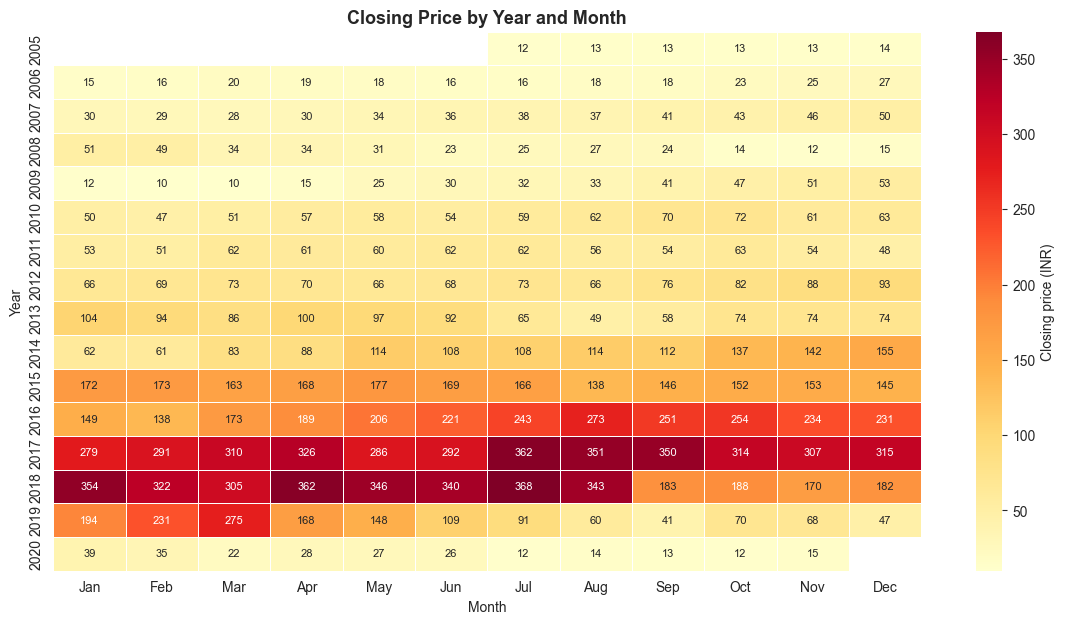

In [32]:
# Chart - 11 visualization code
pivot = df.pivot_table(index='Year', columns='Month', values='Close')
pivot.columns = month_order

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', annot_kws={'size': 8}, linewidths=0.4,
            cbar_kws={'label': 'Closing price (INR)'})
plt.title('Closing Price by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.grid(False)
plt.show()


##### 1. Why did you pick the specific chart?

A heatmap of Year against Month lets us see 185 closing prices at once. Colour shows the level and the numbers show exact values, so we can follow the rise and fall across both time directions.

##### 2. What is/are the insight(s) found from the chart?

The colour moves from pale yellow (2005-2009) to dark red in 2017-2018 and back to pale yellow in 2020. The darkest cells are April 2018 (362), July 2018 (368) and July 2017 (362). There is a sharp colour change between August 2018 (343) and September 2018 (183), which is the cleanest visual of the crash. In 2019 the colours go from orange in March (275) to pale by September (41).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the picture makes the strongest period of the bank easy to identify (2016-2018) and could be shown to management or investors to explain the business cycle.

Negative: the heatmap also shows that the fall took place within a single month in September 2018 (343 to 183), so the risk was not slow-moving. Any early-warning system would need to react at monthly or even shorter intervals.

#### Chart - 12

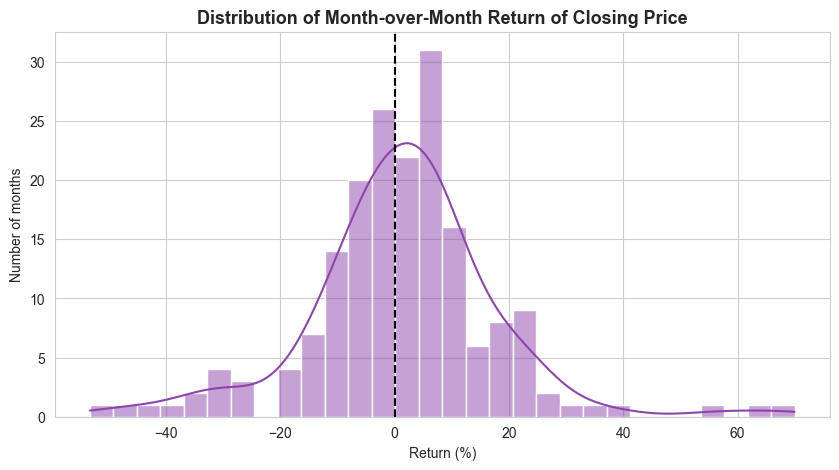

Average return  : 1.5 %
Std deviation   : 16.53 %
Worst month     : -53.32 %  -> Jul 2020
Best month      : 69.96 %  -> Oct 2019


In [33]:
# Chart - 12 visualization code
mom_return = df['Close'].pct_change().dropna() * 100   # month over month change in close

plt.figure(figsize=(10, 5))
sns.histplot(mom_return, bins=30, kde=True, color='#8e44ad')
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribution of Month-over-Month Return of Closing Price')
plt.xlabel('Return (%)')
plt.ylabel('Number of months')
plt.show()

print('Average return  :', round(mom_return.mean(), 2), '%')
print('Std deviation   :', round(mom_return.std(), 2), '%')
print('Worst month     :', round(mom_return.min(), 2), '%  ->', df.loc[mom_return.idxmin(), 'Date'].strftime('%b %Y'))
print('Best month      :', round(mom_return.max(), 2), '%  ->', df.loc[mom_return.idxmax(), 'Date'].strftime('%b %Y'))


##### 1. Why did you pick the specific chart?

A histogram of month-over-month returns shows how large the typical monthly move is and how often extreme moves happen. It is a standard way to look at risk for a price series.

##### 2. What is/are the insight(s) found from the chart?

The returns are centred close to zero (mean about +1.5% per month) but the spread is large, with a standard deviation of about 16.5%. About 61% of months are within +-10% and 83% within +-20%, but 14 months moved by more than 30%. The worst month was July 2020 (-53.3%) and the best month was October 2019 (+70%). The tails on both sides are long, so big moves happen more often than a normal curve would suggest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the average monthly return is positive, so on average the stock rewarded holders over the whole period.

Negative: the very fat tails mean that risk is much higher than the average suggests. A -53% month can destroy the gains of several years, so any business decision using this stock needs risk limits and cannot rely on averages alone. It also tells us the model will have bigger errors in extreme months.

#### Chart - 13

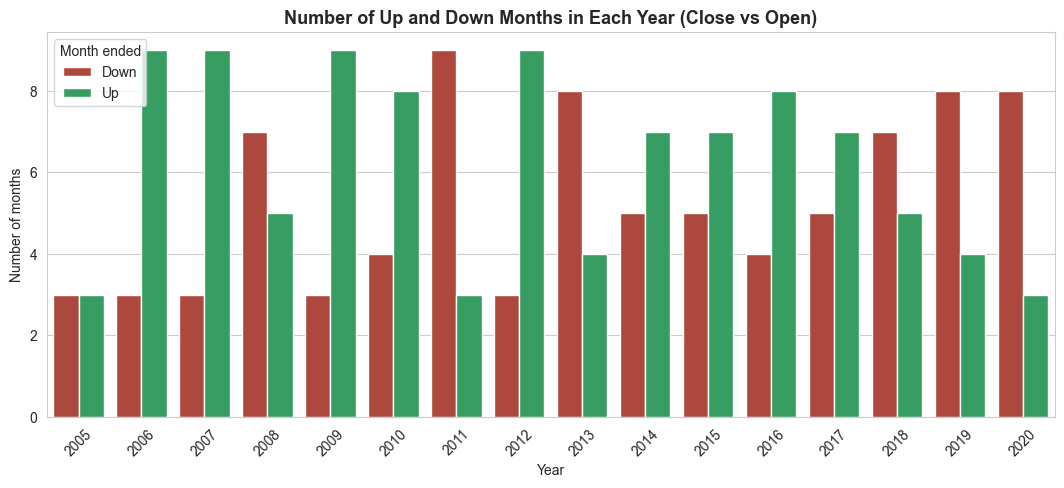

In [34]:
# Chart - 13 visualization code
plt.figure(figsize=(13, 5))
sns.countplot(x='Year', hue='Direction', data=df, palette={'Up': '#27ae60', 'Down': '#c0392b'})
plt.title('Number of Up and Down Months in Each Year (Close vs Open)')
plt.xlabel('Year')
plt.ylabel('Number of months')
plt.xticks(rotation=45)
plt.legend(title='Month ended')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot split by Up/Down gives a quick year-wise view of how consistent the performance was. Years with a clear majority of green bars were healthy years.

##### 2. What is/are the insight(s) found from the chart?

Overall 100 months closed up and 85 closed down. The strongest years were 2006, 2007, 2009 and 2012 with 9 up months out of 12. The weakest were 2011 (9 down months), 2013 (8 down), 2019 (8 down) and 2020 (8 down out of 11). In the peak years 2016 and 2017 up months were 8 and 7, but 2018 already had more down months (7) than up months (5), so the weakness started a bit before the 2019-2020 collapse.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the growth years had a clear majority of up months, which shows the rally was broad-based and not just a couple of lucky months.

Negative: the shift to more down months in 2018 and the very high number in 2019 and 2020 is a sign of negative momentum. The share of down months could be tracked as a simple warning metric.

#### Chart - 14 - Correlation Heatmap

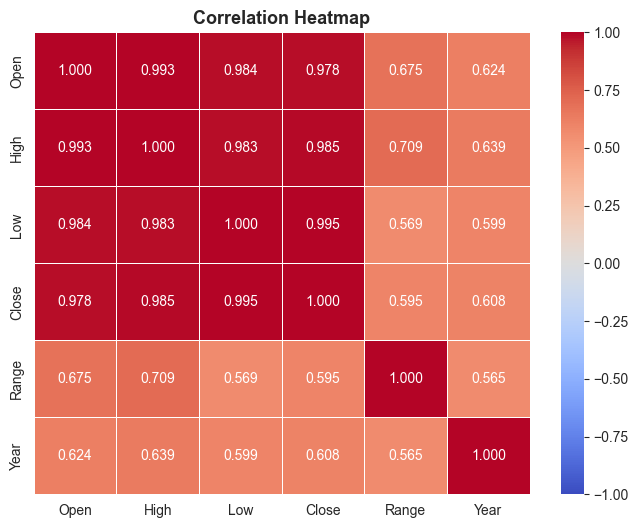

In [35]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
corr = df[['Open', 'High', 'Low', 'Close', 'Range', 'Year']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap shows all pairwise linear relationships at once. It is the quickest way to check which features are related to the target and also which features are related to each other (multicollinearity).

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low and Close are all extremely correlated with each other (0.978 to 0.995). Low has the highest correlation with Close (0.995), then High (0.985) and Open (0.978). Range and Year have only moderate correlation with Close (about 0.6). The strong correlation between the inputs themselves (for example Open and High at 0.993) tells us there is multicollinearity, which is something to handle when choosing the model.

#### Chart - 15 - Pair Plot

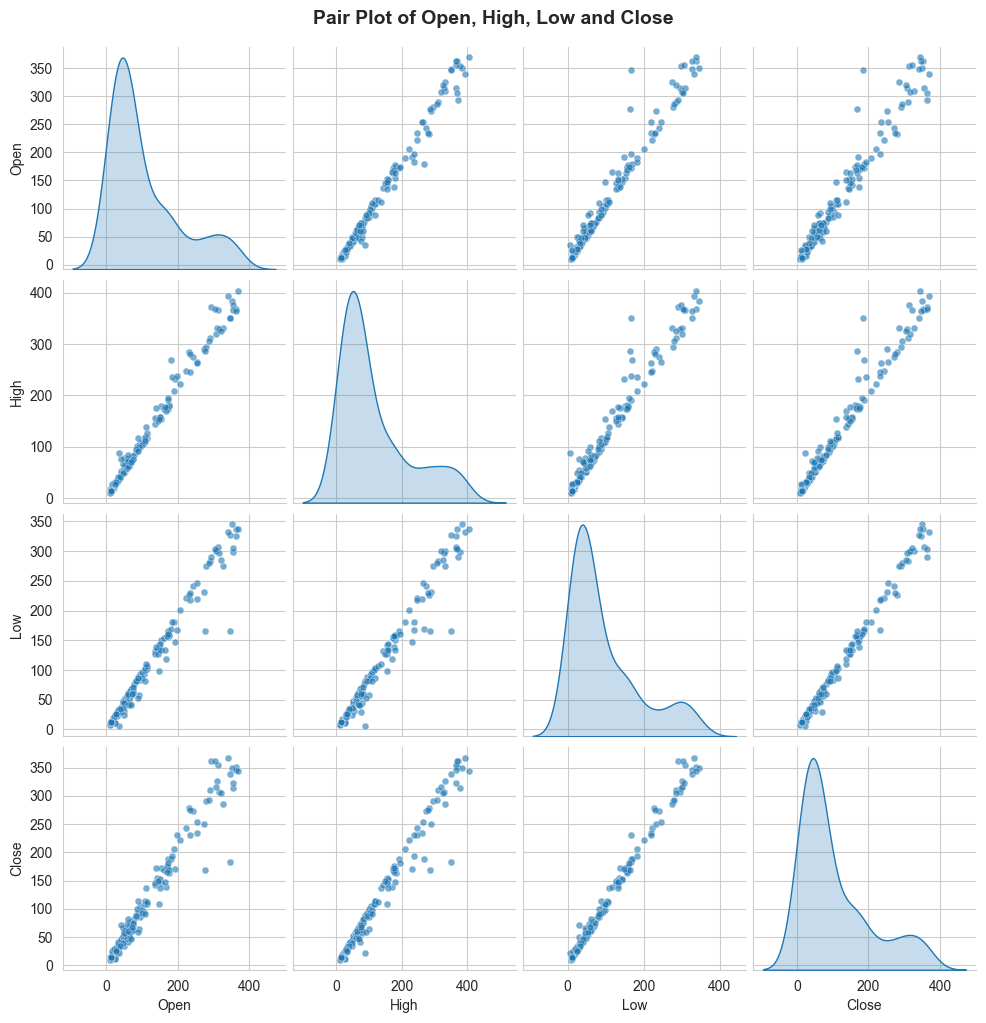

In [36]:
# Pair Plot visualization code
sns.pairplot(df[['Open', 'High', 'Low', 'Close']], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25})
plt.suptitle('Pair Plot of Open, High, Low and Close', y=1.02, fontsize=14, fontweight='bold')
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot gives us every scatter plot and every distribution of the four price columns in one grid. It confirms the relationships we saw in the individual charts.

##### 2. What is/are the insight(s) found from the chart?

The scatter plots between the four variables all look like thin straight bands going up to the right, which confirms the linear relationship. The diagonal KDE plots all show the same right-skewed shape. The points are dense at low prices and sparse at high prices, so the model has fewer examples for the high-price range.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [37]:
# Handling Missing Values & Missing Value Imputation
missing_total = df.isnull().sum().sum()
print('Missing values found:', missing_total)

if missing_total > 0:
    # prices move smoothly month to month, so linear interpolation is a fair fill
    num_cols_all = ['Open', 'High', 'Low', 'Close']
    df[num_cols_all] = df[num_cols_all].interpolate(method='linear')
    print('Filled using linear interpolation')
else:
    print('Nothing to impute, the dataset is complete')


Missing values found: 0
Nothing to impute, the dataset is complete


#### What all missing value imputation techniques have you used and why did you use those techniques?

There were no missing values in any column, so no imputation was actually needed. We still put a small condition in the code: if a missing value ever appears, it will be filled by linear interpolation, because stock prices move smoothly from one month to the next and interpolation would be a sensible fill. Mean or median filling would ignore the time order, which is why we did not choose them.

### 2. Handling Outliers

In [38]:
# Handling Outliers & Outlier treatments
price_cols = ['Open', 'High', 'Low', 'Close']

# IQR rule: anything beyond 1.5 * IQR from Q1 / Q3 is flagged
for col in price_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col:<6} lower limit = {lower:8.2f}  upper limit = {upper:8.2f}  outliers = {len(flagged)}')

# the flagged months in High, just to see which period they come from
q1, q3 = df['High'].quantile([0.25, 0.75])
upper_high = q3 + 1.5 * (q3 - q1)
print('\nMonths with unusually high "High" values:')
display(df.loc[df['High'] > upper_high, ['Date', 'Open', 'High', 'Low', 'Close']])


Open   lower limit =  -145.00  upper limit =   331.80  outliers = 9
High   lower limit =  -163.44  upper limit =   368.76  outliers = 5
Low    lower limit =  -136.25  upper limit =   303.11  outliers = 9
Close  lower limit =  -146.32  upper limit =   333.08  outliers = 9

Months with unusually high "High" values:


,Date,Open,High,Low,Close
144,2017-07-01,293.04,372.00,290.78,361.96
146,2017-09-01,351.00,383.25,345.50,350.00
147,2017-10-01,354.60,375.75,299.00,314.35
156,2018-07-01,340.00,393.35,332.45,367.90
157,2018-08-01,369.95,404.00,338.00,343.40


##### What all outlier treatment techniques have you used and why did you use those techniques?

We checked outliers with the IQR rule (1.5 x IQR). Open, Low and Close have 9 flagged months each and High has 5, and all of them are from the 2017-2018 peak. We decided **not to remove or cap them**. The reasons: (1) they are real market values and not mistakes, (2) with only 185 rows we cannot afford to lose rows, and (3) the model has to work in high-price months too. Instead of deleting them, the log transformation (done below) reduces their influence.

### 3. Categorical Encoding

In [39]:
# Encode your categorical columns
text_cols = df.select_dtypes(exclude=['number', 'datetime']).columns.tolist()
print('Non numeric columns left in the data:', text_cols)

# Month_Name and Direction were made only for the charts. The model will use
# numeric price columns, so there is nothing that has to be encoded.
model_ready_cols = df.select_dtypes(include='number').columns.tolist()
print('Numeric columns:', model_ready_cols)


Non numeric columns left in the data: ['Month_Name', 'Direction']
Numeric columns: ['Open', 'High', 'Low', 'Close', 'Year', 'Month', 'Range', 'Change', 'Change_Pct']


#### What all categorical encoding techniques have you used & why did you use those techniques?

After converting Date into a datetime there is no column in the dataset that needs encoding for the model. Month_Name and Direction are text columns, but they were created only for the charts and are not model inputs. Month is already numeric. So no categorical encoding technique was used.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [40]:
# Expand Contraction
# Not applicable - this dataset has no text column, only dates and prices
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 2. Lower Casing

In [41]:
# Lower Casing
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 3. Removing Punctuations

In [42]:
# Remove Punctuations
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 4. Removing URLs & Removing words and digits contain digits.

In [43]:
# Remove URLs & Remove words and digits contain digits
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 5. Removing Stopwords & Removing White spaces

In [44]:
# Remove Stopwords
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


In [45]:
# Remove White spaces
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 6. Rephrase Text

In [46]:
# Rephrase Text
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 7. Tokenization

In [47]:
# Tokenization
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 8. Text Normalization

In [48]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


##### Which text normalization technique have you used and why?

Not applicable. The dataset has no text data, so no stemming or lemmatization was needed.

#### 9. Part of speech tagging

In [49]:
# POS Taging
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


#### 10. Text Vectorization

In [50]:
# Vectorizing Text
print('Skipped: no textual data in this project')


Skipped: no textual data in this project


##### Which text vectorization technique have you used and why?

Not applicable. There is no text in this project, so no text vectorization was needed.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [51]:
# Manipulate Features to minimize feature correlation and create new features

# new feature: how wide the month's trading range was, relative to the opening price
df['Range_pct'] = (df['High'] - df['Low']) / df['Open'] * 100

# Variance Inflation Factor - tells how much a feature can be explained by the other features
def calc_vif(frame):
    vif = {}
    for col in frame.columns:
        others = frame.drop(columns=col)
        r2 = LinearRegression().fit(others, frame[col]).score(others, frame[col])
        vif[col] = 1 / (1 - r2)
    return pd.Series(vif).sort_values(ascending=False)

print('VIF on raw prices:')
print(calc_vif(df[['Open', 'High', 'Low']]).round(1))
print('\nVIF on log prices:')
print(calc_vif(np.log(df[['Open', 'High', 'Low']])).round(1))
print('\nCorrelation of Range_pct with Close:', round(df['Range_pct'].corr(df['Close']), 3))


VIF on raw prices:
Open    81.9
High    79.2
Low     34.6
dtype: float64

VIF on log prices:
Open    112.5
High     71.4
Low      28.4
dtype: float64

Correlation of Range_pct with Close: -0.237


#### 2. Feature Selection

,F score,RF importance
Low,19574.0,0.7714
High,5984.0,0.1877
Open,4016.9,0.0388
Month,0.6,0.0010
Range_pct,10.9,0.0008
Year,107.6,0.0004


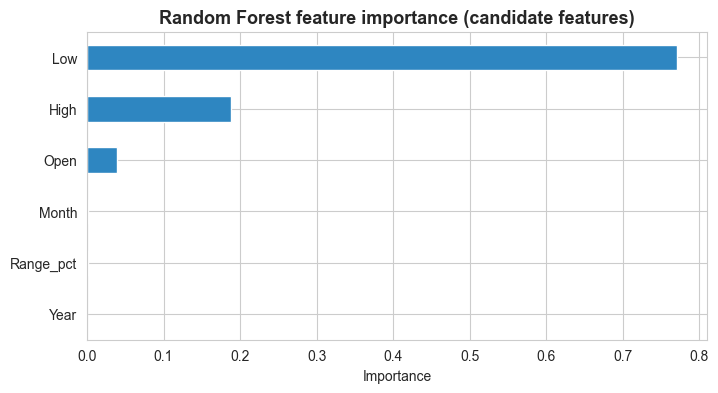

Selected features: ['Open', 'High', 'Low']


In [52]:
# Select your features wisely to avoid overfitting
candidates = ['Open', 'High', 'Low', 'Range_pct', 'Month', 'Year']
X_cand = df[candidates]
y_cand = df['Close']

# 1) univariate F-test
selector = SelectKBest(score_func=f_regression, k='all').fit(X_cand, y_cand)
f_scores = pd.Series(selector.scores_, index=candidates)

# 2) random forest importance
rf_check = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_cand, y_cand)
rf_imp = pd.Series(rf_check.feature_importances_, index=candidates)

summary = pd.DataFrame({'F score': f_scores.round(1), 'RF importance': rf_imp.round(4)}).sort_values('RF importance', ascending=False)
display(summary)

plt.figure(figsize=(8, 4))
rf_imp.sort_values().plot(kind='barh', color='#2e86c1')
plt.title('Random Forest feature importance (candidate features)')
plt.xlabel('Importance')
plt.show()

# final feature list used for modelling
features = ['Open', 'High', 'Low']
print('Selected features:', features)


##### What all feature selection methods have you used  and why?

We used three things together:

1. **F-test (SelectKBest with f_regression)** to see the linear relationship of every candidate feature with Close.
2. **Random forest feature importance**, which can also capture non-linear effects.
3. **VIF (Variance Inflation Factor)** to measure multicollinearity among Open, High and Low. The VIF values are high (about 112 for Open, 71 for High and 28 for Low on log prices), which confirms the inputs overlap a lot.

We tested six candidates: Open, High, Low, Range_pct, Month and Year. Using these tests together is safer than relying on only one method.

##### Which all features you found important and why?

**Low, High and Open** were kept. Low is the most important (F score about 19,574 and random forest importance of 0.77), then High (0.19) and Open (0.04). The other three candidates are almost useless for predicting Close: Month has an F score of only 0.6 and the random forest importance of Month, Range_pct and Year is below 0.002. Adding features that carry no information would only increase the chance of overfitting on 185 rows, so we dropped them. Even though Open, High and Low are correlated with each other, each one adds some information, and the models we use (Ridge, random forest, gradient boosting) are able to handle that correlation.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

       skew before  skew after log
Open         1.266          -0.028
High         1.229          -0.023
Low          1.303          -0.049
Close        1.265          -0.027


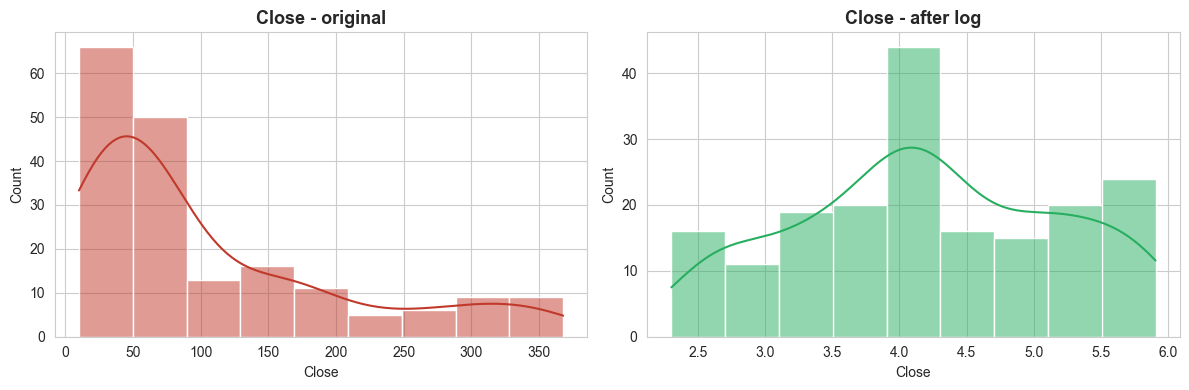


X shape: (185, 3) | y shape: (185,)


In [53]:
# Transform Your data
# skewness before and after taking the log
skew_table = pd.DataFrame({'skew before': df[price_cols].skew(),
                           'skew after log': np.log(df[price_cols]).skew()})
print(skew_table.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Close'], kde=True, ax=ax[0], color='#c0392b')
ax[0].set_title('Close - original')
sns.histplot(np.log(df['Close']), kde=True, ax=ax[1], color='#27ae60')
ax[1].set_title('Close - after log')
plt.tight_layout()
plt.show()

# input and target used for modelling (both in log form)
X = np.log(df[features])
y = np.log(df['Close'])
print('\nX shape:', X.shape, '| y shape:', y.shape)


**Yes, a transformation was needed.** The prices are right-skewed (skewness of about 1.2 to 1.3 for all four columns) and their spread grows with the price level. We applied a **log transformation** to the three input features and to the target. After the log, the skewness is close to 0 (between -0.05 and -0.02) and the relationship between inputs and target becomes more stable across low and high prices. The models are trained on the log values and their predictions are converted back using `exp()` before calculating any score, so all the reported errors are in real rupees.

### 6. Data Scaling

In [54]:
# Scaling your data
print('Mean and std of the (log) features before scaling:')
print(X.describe().loc[['mean', 'std']].round(3))

# only creating the scaler here; it will be fitted on the training part after the split
scaler = StandardScaler()


Mean and std of the (log) features before scaling:
       Open   High    Low
mean  4.215  4.331  4.083
std   0.982  0.956  1.015


##### Which method have you used to scale you data and why?

We used **StandardScaler** (subtract the mean and divide by the standard deviation). Linear and Ridge regression are sensitive to the scale of the inputs, and Ridge in particular penalises large coefficients, so the features should be on the same scale. Standardising was preferred over min-max scaling because the data still has a few extreme values and min-max would be squeezed by them. The scaler is fitted only on the training data and then applied to the test data, to avoid data leakage. (Tree models don't need scaling but it does not harm them, so we use the same scaled data for all three models.)

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, it is not really needed. We only have three input features, so there is no problem of too many dimensions. PCA does show that the first component carries about 98.8% of the variance, because Open, High and Low are so strongly correlated, but compressing them into one component would remove the interpretability (we could no longer say which price drives the prediction) and the models already handle the correlation (Ridge through regularization, trees through their structure).

In [55]:
# DImensionality Reduction (If needed)
# just checking how much variance PCA would capture, not applying it
pca_check = PCA().fit(StandardScaler().fit_transform(X))
print('Explained variance ratio :', np.round(pca_check.explained_variance_ratio_, 4))
print('Cumulative               :', np.round(np.cumsum(pca_check.explained_variance_ratio_), 4))


Explained variance ratio : [0.988  0.0102 0.0019]
Cumulative               : [0.988  0.9981 1.    ]


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was applied. PCA was only run to check the explained variance (98.8%, 1.0% and 0.2% for the three components) and we decided not to use it.

### 8. Data Splitting

In [56]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training rows:', X_train.shape[0])
print('Testing rows :', X_test.shape[0])

# fit the scaler on training data only, then apply the same scaling to the test data
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Training rows: 148
Testing rows : 37


##### What data splitting ratio have you used and why?

We used an **80:20 split** (148 rows for training and 37 rows for testing) with `random_state=42` so the results can be repeated. With only 185 rows, 80% gives the model enough examples to learn from, while 20% still gives a test set big enough for a fair score. A 70:30 split would have taken away too many of the rare high-price months from training. We also used cross-validation inside the training data to tune the models, and as an extra check at the end we tested a time-based split (older 80% months for training, latest 20% for testing).

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No. Class imbalance is a classification problem, and here the target (Close) is a continuous number, so there are no classes to be balanced. We did notice that the price bands are not perfectly even: 31 months closed at 25 or below, 37 between 25 and 50, 53 between 50 and 100, 34 between 100 and 200 and 30 above 200. That is a fairly even spread, so nothing needs correcting.

In [57]:
# Handling Imbalanced Dataset (If needed)
# this is a regression problem, so there are no classes to balance.
# a quick look at how the Close values are spread over price bands:
bands = pd.cut(df['Close'], bins=[0, 25, 50, 100, 200, 400])
print(bands.value_counts().sort_index())
print('\nNo resampling applied.')


Close
(0, 25]       31
(25, 50]      37
(50, 100]     53
(100, 200]    34
(200, 400]    30
Name: count, dtype: int64

No resampling applied.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No technique was used, because the dataset does not need balancing. SMOTE or under/over sampling are for classification problems and would not make sense for a continuous price target.

## ***7. ML Model Implementation***

### ML Model - 1

In [58]:
# helper objects used for all the models

results = []   # every model's scores go here so we can compare them at the end

def get_scores(model, name, X_tr, X_te, y_tr, y_te):
    """Scores on the ORIGINAL price scale (we undo the log with exp)."""
    pred_tr = np.exp(model.predict(X_tr))
    pred_te = np.exp(model.predict(X_te))
    act_tr, act_te = np.exp(y_tr), np.exp(y_te)

    n, p = X_te.shape
    r2_te = r2_score(act_te, pred_te)
    row = {
        'Model': name,
        'Train R2': r2_score(act_tr, pred_tr),
        'Test R2': r2_te,
        'Test Adj R2': 1 - (1 - r2_te) * (n - 1) / (n - p - 1),
        'Train MAE': mean_absolute_error(act_tr, pred_tr),
        'Test MAE': mean_absolute_error(act_te, pred_te),
        'Test MSE': mean_squared_error(act_te, pred_te),
        'Test RMSE': np.sqrt(mean_squared_error(act_te, pred_te)),
        'Test MAPE %': np.mean(np.abs((act_te - pred_te) / act_te)) * 100,
    }
    return row, act_te, pred_te


def plot_scores(row, act_te, pred_te, title):
    fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

    # R2 scores
    r2_names = ['Train R2', 'Test R2', 'Test Adj R2']
    r2_vals = [row[k] for k in r2_names]
    ax[0].bar(r2_names, r2_vals, color=['#85c1e9', '#2e86c1', '#1b4f72'])
    ax[0].set_ylim(min(r2_vals) - 0.02, 1.005)
    for i, v in enumerate(r2_vals):
        ax[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)
    ax[0].set_title('R2 scores')

    # error scores
    err_names = ['Test MAE', 'Test RMSE']
    err_vals = [row[k] for k in err_names]
    ax[1].bar(err_names, err_vals, color=['#f5b041', '#dc7633'])
    for i, v in enumerate(err_vals):
        ax[1].text(i, v + 0.2, f'{v:.2f}', ha='center', fontsize=9)
    ax[1].set_title('Error (INR)')

    # actual vs predicted
    ax[2].scatter(act_te, pred_te, alpha=0.7, color='#8e44ad')
    lims = [min(act_te.min(), pred_te.min()), max(act_te.max(), pred_te.max())]
    ax[2].plot(lims, lims, 'r--', label='perfect prediction')
    ax[2].set_xlabel('Actual close')
    ax[2].set_ylabel('Predicted close')
    ax[2].set_title('Actual vs Predicted (test set)')
    ax[2].legend()

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [59]:
# ML Model - 1 Implementation  (Linear Regression)
lr_model = LinearRegression()

# Fit the Algorithm
lr_model.fit(X_train_s, y_train)

# Predict on the model
lr_row, lr_act, lr_pred = get_scores(lr_model, 'Linear Regression', X_train_s, X_test_s, y_train, y_test)
results.append(lr_row)

print(pd.Series({k: v for k, v in lr_row.items() if k != 'Model'}).round(4))
print('\nCoefficients (scaled log features):', dict(zip(features, lr_model.coef_.round(4))))
print('Intercept:', round(lr_model.intercept_, 4))


Train R2        0.9950
Test R2         0.9912
Test Adj R2     0.9904
Train MAE       3.6666
Test MAE        5.5185
Test MSE       79.6716
Test RMSE       8.9259
Test MAPE %     6.5205
dtype: float64

Coefficients (scaled log features): {'Open': -0.6116, 'High': 0.831, 'Low': 0.776}
Intercept: 4.2211


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Linear Regression** fits a straight-line (more precisely a plane, since we have 3 inputs) relationship between the inputs and the target by minimising the squared error. Because we use log prices, the model effectively says that Close is the product of powers of Open, High and Low. It is simple, fast and easy to explain, which makes it a good baseline.

**Performance (test set, in INR):** R2 = 0.9912, Adjusted R2 = 0.9904, MAE = 5.52, RMSE = 8.93 and MAPE = 6.5%. The train R2 is 0.9950, close to the test R2, so the model is not overfitting. The actual vs predicted plot shows the points sitting along the red line, with the largest misses at higher prices. One thing to notice is that the coefficient of Open is negative (about -0.61 on the scaled data) while High and Low are positive (0.83 and 0.78). This is a typical effect of multicollinearity: Open and High carry overlapping information so the model balances one against the other. It does not hurt predictions, but we should not read the individual coefficients as "effect of Open".

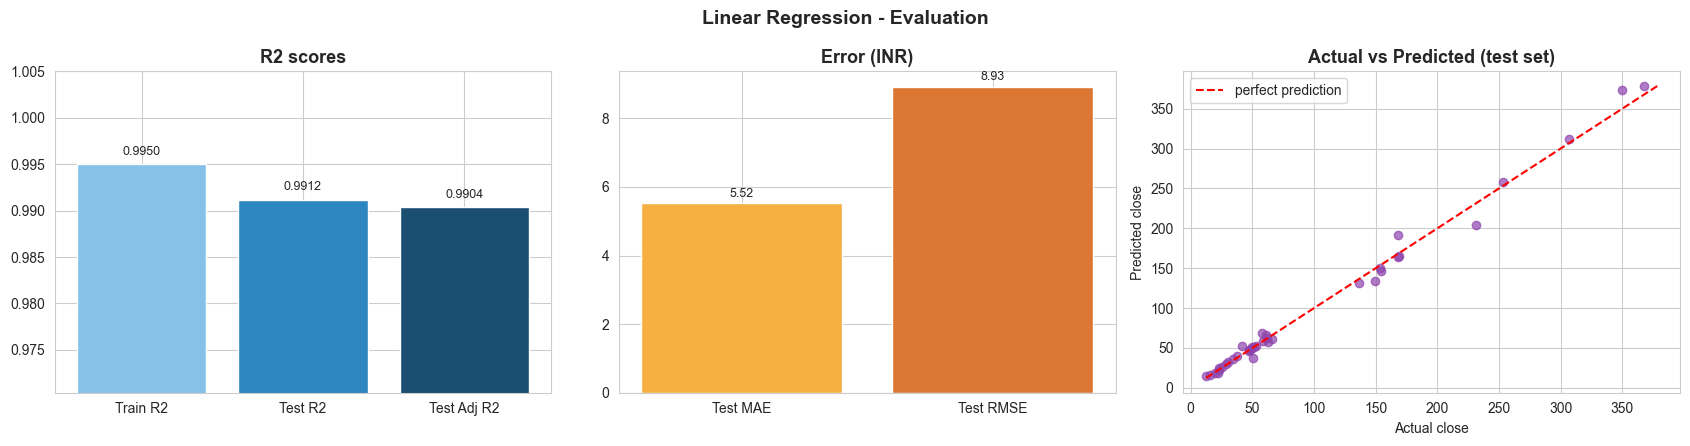

In [60]:
# Visualizing evaluation Metric Score chart
plot_scores(lr_row, lr_act, lr_pred, 'Linear Regression - Evaluation')


#### 2. Cross- Validation & Hyperparameter Tuning

Linear Regression 5-fold CV R2 (log scale): 0.9939
Best alpha: 0.001
Best CV RMSE (log scale): 0.0689

Before vs after tuning


,Train R2,Test R2,Test Adj R2,Train MAE,Test MAE,Test MSE,Test RMSE,Test MAPE %
Model,,,,,,,,
Linear Regression,0.995,0.9912,0.9904,3.6666,5.5185,79.6716,8.9259,6.5205
Ridge (tuned),0.995,0.9912,0.9904,3.6684,5.5181,79.6781,8.9263,6.5193


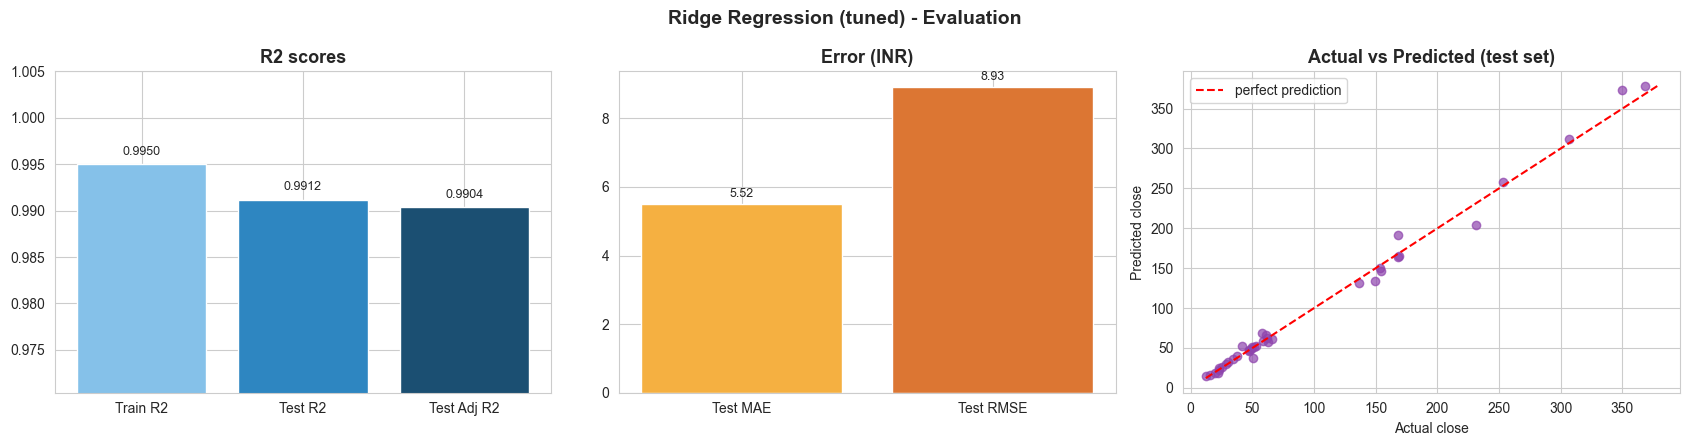

In [61]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (Ridge + GridSearchCV)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# cross validation score of the plain linear regression, for reference
lr_cv = cross_val_score(LinearRegression(), X_train_s, y_train, cv=cv, scoring='r2')
print('Linear Regression 5-fold CV R2 (log scale): %.4f' % lr_cv.mean())

ridge_grid = GridSearchCV(Ridge(), param_grid={'alpha': np.logspace(-3, 3, 30)},
                          cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the Algorithm
ridge_grid.fit(X_train_s, y_train)
print('Best alpha:', round(ridge_grid.best_params_['alpha'], 4))
print('Best CV RMSE (log scale): %.4f' % np.sqrt(-ridge_grid.best_score_))

# Predict on the model
best_ridge = ridge_grid.best_estimator_
ridge_row, ridge_act, ridge_pred = get_scores(best_ridge, 'Ridge (tuned)', X_train_s, X_test_s, y_train, y_test)
results.append(ridge_row)

print('\nBefore vs after tuning')
display(pd.DataFrame([lr_row, ridge_row]).set_index('Model').round(4))
plot_scores(ridge_row, ridge_act, ridge_pred, 'Ridge Regression (tuned) - Evaluation')


##### Which hyperparameter optimization technique have you used and why?

We used **GridSearchCV** with 5-fold cross-validation on a **Ridge regression**, which is Linear Regression with an L2 penalty (alpha). Plain linear regression has no hyperparameters to tune, and since our inputs are strongly correlated (VIF up to 112), Ridge is the natural way to check whether shrinking the coefficients helps. The grid has 30 values of alpha between 0.001 and 1000. Grid search was fine here because there is only one parameter, so searching every value is cheap and complete.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No real improvement. The best alpha was 0.001, which is the smallest value in the grid, so the best Ridge is almost the same as normal linear regression. Test R2 stayed at 0.9912, MAE went from 5.5185 to 5.5181 and RMSE from 8.9259 to 8.9263, which are practically identical. This tells us that regularization is not needed here, the data is simple and linear enough after the log transform. The 5-fold CV R2 of plain linear regression (0.9939, measured on the log scale) is in line with the test score, so the result looks stable.

### ML Model - 2

In [62]:
# ML Model - 2 Implementation  (Random Forest Regressor)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

# Fit the Algorithm
rf_model.fit(X_train_s, y_train)

# Predict on the model
rf_row, rf_act, rf_pred = get_scores(rf_model, 'Random Forest', X_train_s, X_test_s, y_train, y_test)
results.append(rf_row)

print(pd.Series({k: v for k, v in rf_row.items() if k != 'Model'}).round(4))
print('\nFeature importance:', dict(zip(features, rf_model.feature_importances_.round(4))))


Train R2         0.9985
Test R2          0.9823
Test Adj R2      0.9807
Train MAE        2.2329
Test MAE         8.0023
Test MSE       160.2132
Test RMSE       12.6575
Test MAPE %     12.6144
dtype: float64

Feature importance: {'Open': 0.0487, 'High': 0.388, 'Low': 0.5633}


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest Regressor** builds many decision trees on random samples of the data and averages their predictions. It can capture non-linear relationships and is not affected by feature scaling. We used 200 trees as the starting point.

**Performance (test set):** R2 = 0.9823, Adjusted R2 = 0.9807, MAE = 8.00, RMSE = 12.66 and MAPE = 12.6%. The train R2 (0.9985) is higher than the test R2, so it overfits a bit, and its error is clearly larger than linear regression's. The reason is that trees predict by averaging values they have already seen, so they cannot go beyond the price range of the training data and they work in steps rather than along a smooth line, which does not suit a relationship that is almost perfectly linear. Feature importance: Low = 0.56, High = 0.39, Open = 0.05.

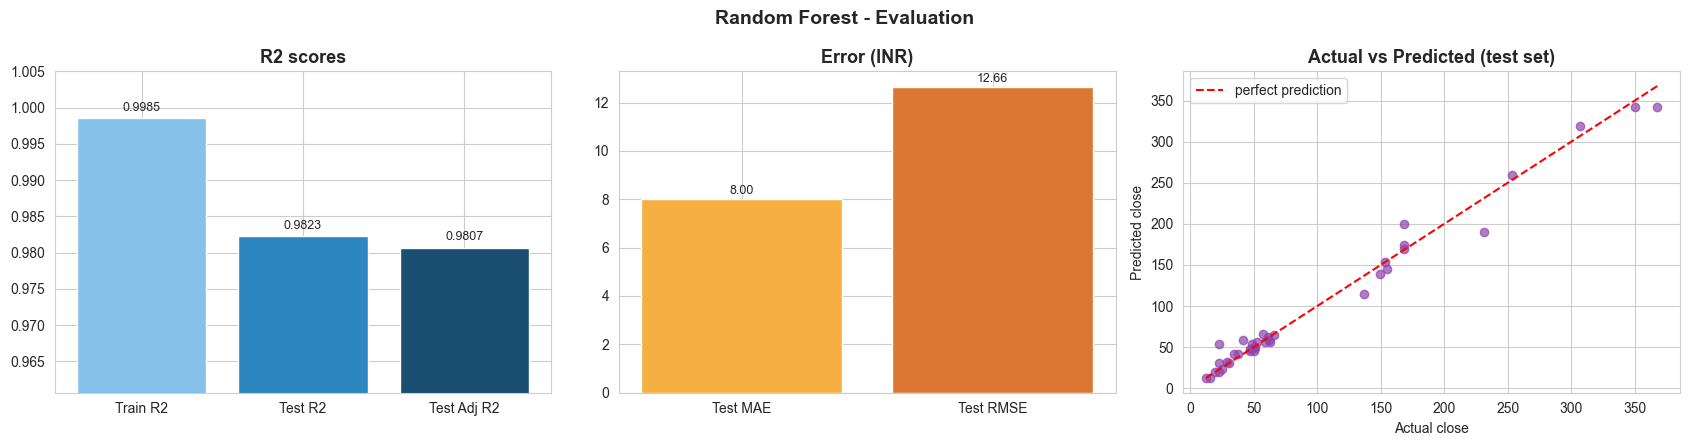

In [63]:
# Visualizing evaluation Metric Score chart
plot_scores(rf_row, rf_act, rf_pred, 'Random Forest - Evaluation')


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (RandomizedSearchCV)
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 4, 6, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42), rf_params, n_iter=25,
                               cv=cv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)

# Fit the Algorithm
rf_search.fit(X_train_s, y_train)
print('Best parameters:', rf_search.best_params_)
print('Best CV RMSE (log scale): %.4f' % np.sqrt(-rf_search.best_score_))

# Predict on the model
best_rf = rf_search.best_estimator_
rf_t_row, rf_t_act, rf_t_pred = get_scores(best_rf, 'Random Forest (tuned)', X_train_s, X_test_s, y_train, y_test)
results.append(rf_t_row)

print('\nBefore vs after tuning')
display(pd.DataFrame([rf_row, rf_t_row]).set_index('Model').round(4))
plot_scores(rf_t_row, rf_t_act, rf_t_pred, 'Random Forest (tuned) - Evaluation')


##### Which hyperparameter optimization technique have you used and why?

We used **RandomizedSearchCV** (25 random combinations, 5-fold CV). A random forest has several parameters (number of trees, depth, minimum samples per split and leaf, number of features per split), and trying every combination would take 4 x 5 x 4 x 3 x 3 = 720 combinations x 5 folds. Random search covers the space well with a small fraction of that time.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No, not really. The best parameters were 500 trees, max_depth = 5, min_samples_leaf = 2 and max_features = None, which lowered the train R2 from 0.9985 to 0.9972 (less overfitting), but the test R2 stayed the same (0.9823 to 0.9822) and the test RMSE moved from 12.66 to 12.70. The cross-validated score picked this combination but the 37-row test set is small, so these tiny differences are just noise. The overall conclusion is that tuning controlled overfitting a little but did not make the model more accurate.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

What the metrics mean for the business:

- **MAE (about 5.5 INR for the best model):** on average the estimate is off by about 5.5 rupees per share. It is easy to understand and is the "typical miss".
- **MSE / RMSE (about 8.9 INR):** these punish big mistakes more. RMSE is higher than MAE, which says that some months have large errors (usually the high-priced or crash months). For risk management, RMSE is the more cautious number.
- **MAPE (about 6.5%):** the error as a percentage of price. This is useful because a 5 rupee error is a big deal when the price is 12 but small when it is 350.
- **R2 / Adjusted R2 (0.991 / 0.990):** the model explains more than 99% of the variation in the closing price. Adjusted R2 is nearly the same as R2, which shows that the three features are not being added for no reason.

Business impact: the model can be used for quickly estimating the month-end closing price from the month's trading range, for filling gaps and for sanity checks in reports or dashboards. It should not be used as a trading signal on its own, because the inputs (High and Low) are only known late in the month, and the errors grow in the crash months, which are exactly the months where mistakes are expensive. This is an analytical project, not investment advice.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation  (Gradient Boosting Regressor)
gb_model = GradientBoostingRegressor(random_state=42)

# Fit the Algorithm
gb_model.fit(X_train_s, y_train)

# Predict on the model
gb_row, gb_act, gb_pred = get_scores(gb_model, 'Gradient Boosting', X_train_s, X_test_s, y_train, y_test)
results.append(gb_row)

print(pd.Series({k: v for k, v in gb_row.items() if k != 'Model'}).round(4))
print('\nFeature importance:', dict(zip(features, gb_model.feature_importances_.round(4))))


Train R2         0.9994
Test R2          0.9798
Test Adj R2      0.9780
Train MAE        1.3667
Test MAE         8.6735
Test MSE       182.2102
Test RMSE       13.4985
Test MAPE %     14.4775
dtype: float64

Feature importance: {'Open': 0.005, 'High': 0.4301, 'Low': 0.5649}


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Gradient Boosting Regressor** also uses decision trees, but it builds them one after another, and each new small tree tries to correct the errors left by the previous ones. It is a strong general-purpose model and often performs very well on tabular data. We used the default settings first (100 trees, learning rate 0.1, depth 3).

**Performance (test set):** R2 = 0.9798, Adjusted R2 = 0.9780, MAE = 8.67, RMSE = 13.50 and MAPE = 14.5%. The train R2 is 0.9994, so there is a visible gap between training and testing performance, meaning it overfits the training months. It was the weakest of the three models on this dataset. Feature importance: Low = 0.56, High = 0.43 and Open is almost zero (0.005).

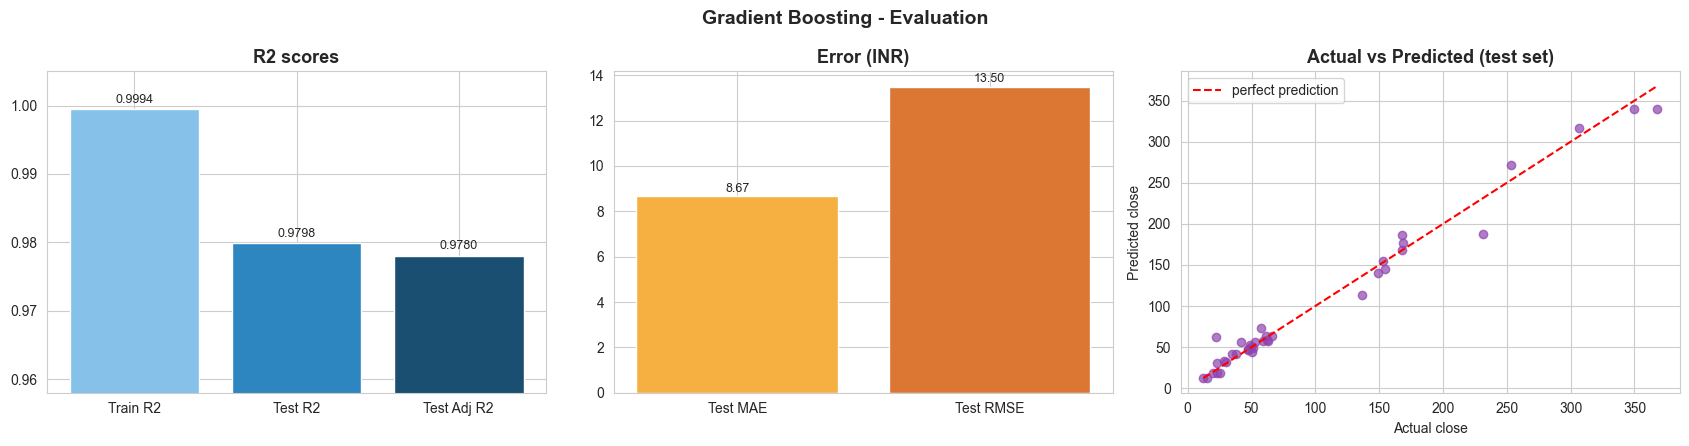

In [ ]:
# Visualizing evaluation Metric Score chart
plot_scores(gb_row, gb_act, gb_pred, 'Gradient Boosting - Evaluation')


#### 2. Cross- Validation & Hyperparameter Tuning

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV RMSE (log scale): 0.0975

Before vs after tuning


,Train R2,Test R2,Test Adj R2,Train MAE,Test MAE,Test MSE,Test RMSE,Test MAPE %
Model,,,,,,,,
Gradient Boosting,0.9994,0.9798,0.9780,1.3667,8.6735,182.2102,13.4985,14.4775
Gradient Boosting (tuned),1.0000,0.9790,0.9771,0.3700,8.8600,189.7241,13.7740,14.7927


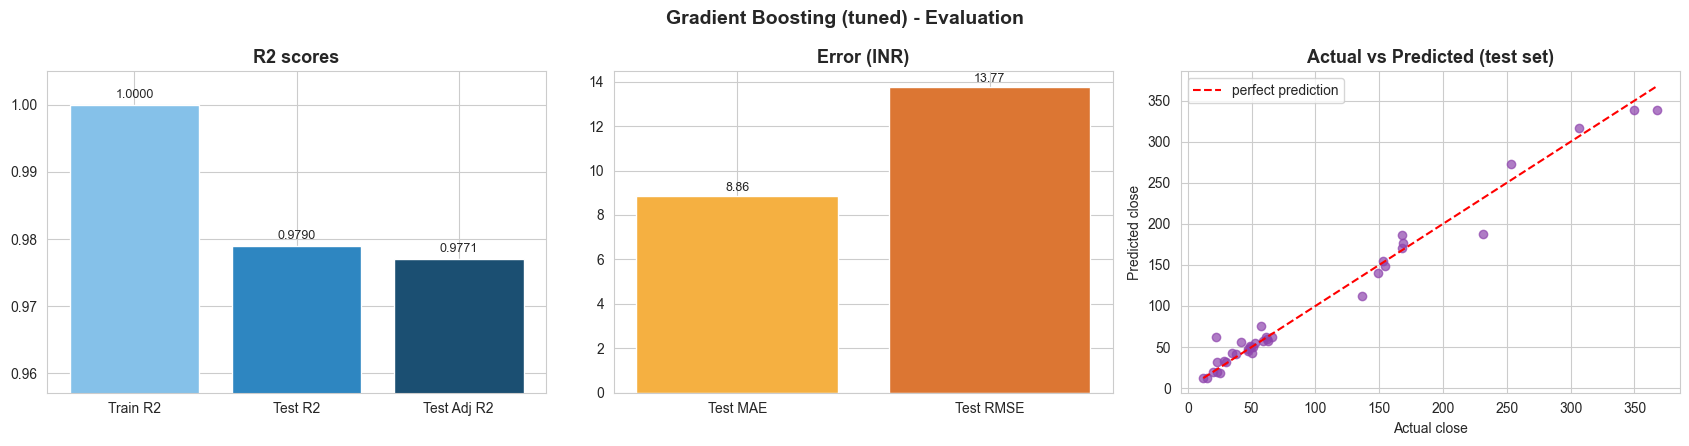

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (GridSearchCV)
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0],
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params,
                       cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit the Algorithm
gb_grid.fit(X_train_s, y_train)
print('Best parameters:', gb_grid.best_params_)
print('Best CV RMSE (log scale): %.4f' % np.sqrt(-gb_grid.best_score_))

# Predict on the model
best_gb = gb_grid.best_estimator_
gb_t_row, gb_t_act, gb_t_pred = get_scores(best_gb, 'Gradient Boosting (tuned)', X_train_s, X_test_s, y_train, y_test)
results.append(gb_t_row)

print('\nBefore vs after tuning')
display(pd.DataFrame([gb_row, gb_t_row]).set_index('Model').round(4))
plot_scores(gb_t_row, gb_t_act, gb_t_pred, 'Gradient Boosting (tuned) - Evaluation')


##### Which hyperparameter optimization technique have you used and why?

We used **GridSearchCV** over n_estimators (100, 200, 300), learning_rate (0.03, 0.05, 0.1), max_depth (2, 3, 4) and subsample (0.8, 1.0), which is 54 combinations with 5-fold CV. The grid is small enough to be searched fully, and boosting models are sensitive to the combination of learning rate and number of trees, so an exhaustive search is more reliable here than a random one.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No improvement on the test set. The best parameters (learning_rate = 0.1, max_depth = 3, n_estimators = 300, subsample = 1.0) pushed the train R2 to 1.0000 but the test R2 fell slightly from 0.9798 to 0.9790 and the test RMSE rose from 13.50 to 13.77. So the tuned model fits the training data even more tightly and generalises a little worse, which is an overfitting sign. With only 148 training rows, the cross-validation winner is not guaranteed to be the test winner.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

,Train R2,Test R2,Test Adj R2,Train MAE,Test MAE,Test MSE,Test RMSE,Test MAPE %
Model,,,,,,,,
Linear Regression,0.9950,0.9912,0.9904,3.6666,5.5185,79.6716,8.9259,6.5205
Ridge (tuned),0.9950,0.9912,0.9904,3.6684,5.5181,79.6781,8.9263,6.5193
Random Forest,0.9985,0.9823,0.9807,2.2329,8.0023,160.2132,12.6575,12.6144
Random Forest (tuned),0.9972,0.9822,0.9805,3.1781,8.1634,161.2600,12.6988,13.0534
Gradient Boosting,0.9994,0.9798,0.9780,1.3667,8.6735,182.2102,13.4985,14.4775
Gradient Boosting (tuned),1.0000,0.9790,0.9771,0.3700,8.8600,189.7241,13.7740,14.7927


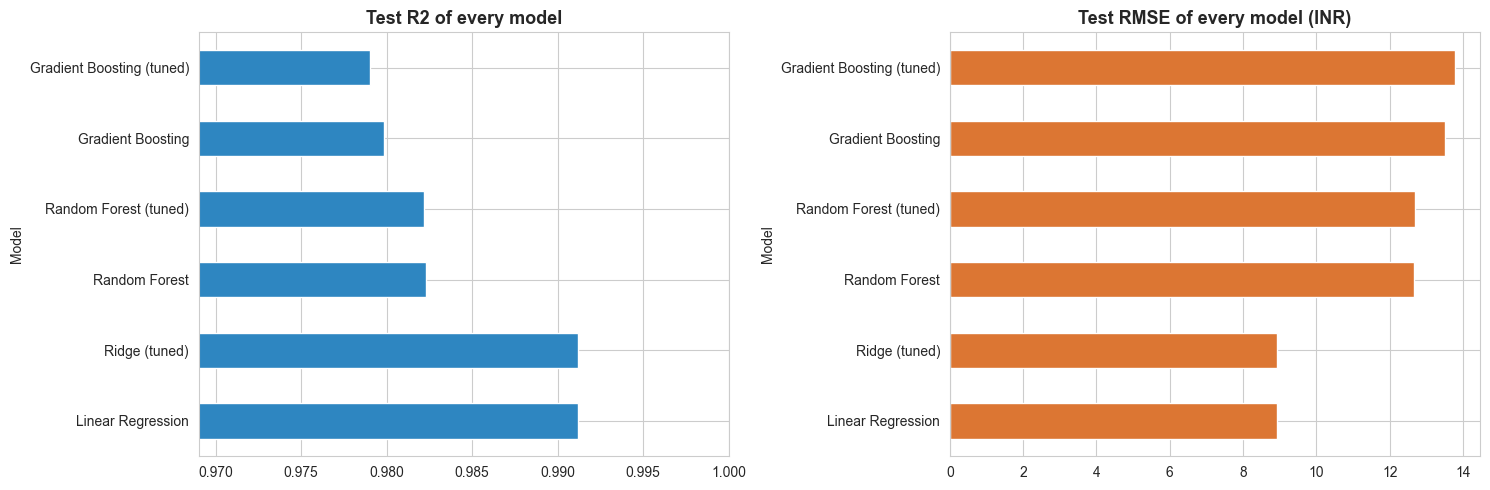

In [ ]:
# comparing all the models side by side
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
results_df['Test R2'].plot(kind='barh', ax=ax[0], color='#2e86c1')
ax[0].set_title('Test R2 of every model')
ax[0].set_xlim(results_df['Test R2'].min() - 0.01, 1.0)
results_df['Test RMSE'].plot(kind='barh', ax=ax[1], color='#dc7633')
ax[1].set_title('Test RMSE of every model (INR)')
plt.tight_layout()
plt.show()


In [ ]:
# extra check: train on the older 80% of months and test on the latest 20%
# (closer to how the model would really be used - it has never seen the 2018-2020 price levels)
cut = int(len(df) * 0.8)
tr_idx, te_idx = df.index[:cut], df.index[cut:]

sc_time = StandardScaler().fit(X.loc[tr_idx])
Xt_train, Xt_test = sc_time.transform(X.loc[tr_idx]), sc_time.transform(X.loc[te_idx])
yt_train, yt_test = y.loc[tr_idx], y.loc[te_idx]

time_models = {
    'Ridge (tuned)': Ridge(**ridge_grid.best_params_),
    'Random Forest (tuned)': RandomForestRegressor(**rf_search.best_params_, random_state=42),
    'Gradient Boosting (tuned)': GradientBoostingRegressor(**gb_grid.best_params_, random_state=42),
}

time_rows = []
for name, m in time_models.items():
    m.fit(Xt_train, yt_train)
    row, _, _ = get_scores(m, name, Xt_train, Xt_test, yt_train, yt_test)
    time_rows.append(row)

print('Train period:', df.loc[tr_idx[0], 'Date'].strftime('%b %Y'), 'to', df.loc[tr_idx[-1], 'Date'].strftime('%b %Y'))
print('Test period :', df.loc[te_idx[0], 'Date'].strftime('%b %Y'), 'to', df.loc[te_idx[-1], 'Date'].strftime('%b %Y'))
display(pd.DataFrame(time_rows).set_index('Model')[['Train R2', 'Test R2', 'Test MAE', 'Test RMSE', 'Test MAPE %']].round(4))


Train period: Jul 2005 to Oct 2017
Test period : Nov 2017 to Nov 2020


,Train R2,Test R2,Test MAE,Test RMSE,Test MAPE %
Model,,,,,
Ridge (tuned),0.9969,0.9847,9.5672,15.8703,8.3357
Random Forest (tuned),0.9968,0.9758,12.9448,19.9330,13.9646
Gradient Boosting (tuned),1.0000,0.9755,11.3537,20.0382,11.3948


We chose the **Ridge / Linear Regression model** as the final model (the tuned Ridge, alpha = 0.001, which is practically the same as Linear Regression).

Why:

- It has the best test scores on every metric: R2 = 0.9912, RMSE = 8.93, MAE = 5.52 and MAPE = 6.5%, against RMSE of 12.7 for the random forest and 13.8 for gradient boosting.
- It has the smallest gap between train and test scores (0.9950 vs 0.9912), so it is the one least affected by overfitting. Both tree models fit the training set better and then do worse on the test set.
- It also won the extra time-based check, where the models were trained on Jul 2005 - Oct 2017 and tested on Nov 2017 - Nov 2020: Ridge test R2 = 0.9847 (RMSE 15.9) against 0.9758 for the random forest and 0.9755 for gradient boosting.
- It is simple, fast, and easy to explain to non-technical people.

The reason that the simplest model wins is that after the log transform the relationship between Open/High/Low and Close is almost perfectly linear, so there is not much left for complex non-linear models to find.

# **Conclusion**

In this project we used 185 months of Yes Bank stock prices (July 2005 to November 2020) to build a regression model that predicts the closing price from the month's Open, High and Low prices.

**Main findings from the data:**
- The data is clean (no missing values, no duplicates, no gaps in the timeline). The price rose from about 12 in 2005 to a peak close of 367.9 in July 2018, and then fell by roughly 97% to about 12 in July 2020.
- Prices are right-skewed with a growing spread, so we log-transformed the features and the target.
- Open, High and Low are all very strongly correlated with Close (0.978, 0.985 and 0.995) and also with each other (VIF up to 112), and Low is the single most useful feature.
- Month-to-month returns have fat tails (a worst month of -53% and a best month of +70%), which is where all the models make their largest errors.

**Modelling results (test set, original price scale):**

| Model | Test R2 | MAE | RMSE |
|---|---|---|---|
| Linear Regression | 0.9912 | 5.52 | 8.93 |
| Ridge (tuned) | 0.9912 | 5.52 | 8.93 |
| Random Forest | 0.9823 | 8.00 | 12.66 |
| Random Forest (tuned) | 0.9822 | 8.16 | 12.70 |
| Gradient Boosting | 0.9798 | 8.67 | 13.50 |
| Gradient Boosting (tuned) | 0.9790 | 8.86 | 13.77 |

The final model is the (tuned) Ridge regression, which explains about 99% of the variance with an average error of about 5.5 rupees per share. Hyperparameter tuning did not improve any of the models on the test set, which is a useful result by itself: more complexity was not what this data needed.

**Limitations and next steps:** the model estimates the month-end close using High and Low of the same month, which are known only once the month is nearly complete, so it is an estimation tool and not a forecast of the future price. The errors are largest in extreme months (like September 2018 and March 2020), and the dataset has just 185 rows. To make a real forecasting model we would add lagged features (previous months' prices and returns), try time-series models such as ARIMA or LSTM, and bring in outside information like news or banking-sector indicators. The results here are for learning and analysis and are not investment advice.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***